# Experimentation and Uplift Testing

## Objective

The objective of this analysis is to evaluate the effectiveness of the trial store layouts implemented in Stores 77, 86, and 88.
To assess the impact of the trial, suitable control stores are identified using historical sales performance. The performance of each trial store is then compared with its control store during the trial period.

The analysis focuses on:
- Total Sales Revenue
- Number of Customers
- Transactions per Customer

The final goal is to determine whether the trial layout led to a significant improvement in store performance and provide recommendations for future rollout.

In [2]:
#import libarires 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# import the csv file
data = pd.read_csv("C:\\Users\\Suraj\\Documents\\Data analysis\\Customer Purchase Analysis\\merged_data.csv")
data.sample(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
176212,2018-10-23,83,83029,82252,37,Smiths Thinly Swt Chli&S/Cream175G,2,6.0,175,Smiths,RETIREES,Premium
50691,2019-03-13,213,213038,212084,51,Doritos Mexicana 170g,2,8.8,170,Doritos,OLDER FAMILIES,Budget
113207,2019-01-26,207,207137,205408,105,Woolworths Cheese Rings 190g,2,3.6,190,Woolworths,OLDER SINGLES/COUPLES,Mainstream
188726,2018-09-02,56,56011,50077,28,Thins Potato Chips Hot & Spicy 175g,2,6.6,175,Thins,YOUNG FAMILIES,Budget
173188,2019-06-28,20,20004,16949,34,Pringles Slt Vingar 134g,1,3.7,134,Pringles,RETIREES,Premium


In [34]:
# Create YearMonth column 
data["DATE"] = pd.to_datetime(data["DATE"])

data["YEARMONTH"] = (
    data["DATE"].dt.year *100
    + data["DATE"].dt.month
)


0         False
1         False
2         False
3         False
4         False
          ...  
264829    False
264830    False
264831    False
264832     True
264833    False
Name: YEARMONTH, Length: 264834, dtype: bool

## Monthly Store Performance Metrics

To evaluate store performance, monthly metrics were calculated for each store. These metrics include:

- Total Sales Revenue
- Number of Unique Customers
- Number of Transactions
- Average Transactions per Customer

These metrics form the basis for identifying suitable control stores and assessing the impact of the trial.

In [50]:
# Calculate Monthly Metrics
monthly_metric = data.groupby(
    ["STORE_NBR","YEARMONTH"]
    ).agg(
        Total_sales = ("TOT_SALES","sum"),
        Customers = ("LYLTY_CARD_NBR","nunique"),
        Transcations = ("TXN_ID","nunique")
    ).reset_index()

monthly_metric["txn_per_customer"] = (
    monthly_metric["Transcations"]
    / monthly_metric["Customers"]
)
monthly_metric["txn_per_customer"].astype(int)
monthly_metric

#------------------------------------------------------------------------------------------------------------------------------------------------------

# store history
store_months = monthly_metric.groupby(
    "STORE_NBR"
)["YEARMONTH"].nunique()

valid_stores = store_months[
    store_months >= 10
].index

#------------------------------------------------------------------------------------------------------------------------------------------------------

# filter the data
filtered_data = monthly_metric[
    monthly_metric["STORE_NBR"].isin(valid_stores)
]

## Control Store Selection

To measure the impact of the trial accurately, a control store was selected for each trial store.

Control stores were identified based on:
1. Correlation of monthly sales trends.
2. Magnitude similarity of sales values.

Stores with highly similar historical performance before the trial period were considered suitable control stores.

A combined similarity score was used to determine the best match for each trial store.

In [62]:
# identify trail stores
trial_stores = [77,86,88]
trial_stores

#------------------------------------------------------------------------------------------------------------------------------------------------------

# Remove trial stores 
control_can = monthly_metric[
    ~monthly_metric["STORE_NBR"].isin(trial_stores)
]
#------------------------------------------------------------------------------------------------------------------------------------------------------

# pre trial month
pre_trial = filtered_data[
    filtered_data["YEARMONTH"] < 201902
]
#------------------------------------------------------------------------------------------------------------------------------------------------------

# trial 77 
trial77 = pre_trial[
    pre_trial["STORE_NBR"] == 77
]
trial77.head()
#------------------------------------------------------------------------------------------------------------------------------------------------------


# define a function for finding the control store
def find_control_store(trial_store):

    trial_data = pre_trial[
        pre_trial["STORE_NBR"] == trial_store
    ][["YEARMONTH","Total_sales"]]

    scores = []

    for store in pre_trial["STORE_NBR"].unique():

        if store in [77,86,88]:
            continue

        candidate = pre_trial[
            pre_trial["STORE_NBR"] == store
        ][["YEARMONTH","Total_sales"]]

        merged = trial_data.merge(
            candidate,
            on="YEARMONTH",
            suffixes=("_trial","_control")
        )

        # Require at least 7 months
        if len(merged) >= 7:

            # Correlation score
            corr_score = merged["Total_sales_trial"].corr(
                merged["Total_sales_control"]
            )

            # Magnitude similarity
            sales_diff = abs(
                merged["Total_sales_trial"] -
                merged["Total_sales_control"]
            )

            avg_diff = sales_diff.mean()

            scores.append([
                store,
                corr_score,
                avg_diff
            ])

    result = pd.DataFrame(
        scores,
        columns=[
            "STORE_NBR",
            "Correlation",
            "Avg_Difference"
        ]
    )

    # Normalize magnitude score
    max_diff = result["Avg_Difference"].max()
    min_diff = result["Avg_Difference"].min()

    result["Magnitude_Score"] = 1 - (
        (result["Avg_Difference"] - min_diff)
        /
        (max_diff - min_diff)
    )

    # Final score
    result["Final_Score"] = (
        result["Correlation"]
        +
        result["Magnitude_Score"]
    ) / 2

    return result.sort_values(
        "Final_Score",
        ascending=False
    )
#------------------------------------------------------------------------------------------------------------------------------------------------------

find_control_store(77).head(10)
find_control_store(86).head(10)
find_control_store(88).head(10)

,STORE_NBR,Correlation,Avg_Difference,Magnitude_Score,Final_Score
114,125,0.624109,196.550000,0.890950,0.757529
191,203,0.508001,66.100000,0.993943,0.750972
82,91,0.776688,450.514286,0.690439,0.733564
6,7,0.649657,295.728571,0.812646,0.731151
167,178,0.731857,405.585714,0.725911,0.728884
189,201,0.492735,169.742857,0.912115,0.702425
96,106,0.644724,399.592857,0.730643,0.687683
73,79,0.576960,320.064286,0.793432,0.685196
222,237,0.308479,58.428571,1.000000,0.654240
144,155,0.600771,439.271429,0.699315,0.650043


## Selected Control Stores

Based on the similarity analysis, the following control stores were selected:

| Trial Store | Control Store |
|------------|--------------|
| 77 | 233 |
| 86 | 155 |
| 88 | 125 |

These stores demonstrated similar sales patterns and sales magnitudes during the pre-trial period, making them appropriate benchmarks for comparison.

In [69]:
# make trial_control pair for store 77
trial_77 = monthly_metric[
    monthly_metric["STORE_NBR"] == 77
].sort_values("YEARMONTH")

control_233 = monthly_metric[
    monthly_metric["STORE_NBR"] == 233
].sort_values("YEARMONTH")

#------------------------------------------------------------------------------------------------------------------------------------------------------

# make trial_control pair for store 86
trial_86 = monthly_metric[
    monthly_metric["STORE_NBR"] == 86
].sort_values("YEARMONTH")

control_155 = monthly_metric[
    monthly_metric["STORE_NBR"] == 155
].sort_values("YEARMONTH")

#------------------------------------------------------------------------------------------------------------------------------------------------------

# make trial_control pair for store 88
trial_88 = monthly_metric[
    monthly_metric["STORE_NBR"] == 88
].sort_values("YEARMONTH")

control_125 = monthly_metric[
    monthly_metric["STORE_NBR"] == 125
].sort_values("YEARMONTH")

## Trial Store vs Control Store Comparison

To validate the suitability of the selected control stores, monthly sales trends were visualized for each trial-control pair.

The visual comparison helps confirm that the selected control stores followed similar performance patterns before the trial period.

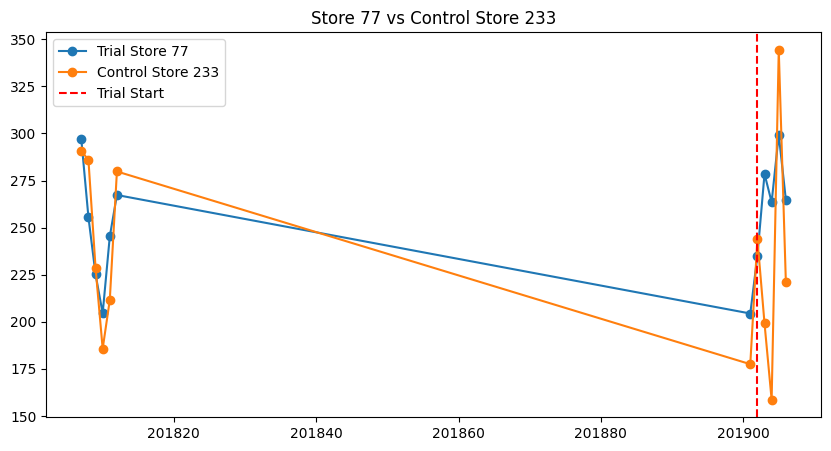

In [79]:
#------------------------------------------------------------------------------------------------------------------------------------------------------
# sort the data 
trial_77 = trial_77.sort_values("YEARMONTH")
control_233 = control_233.sort_values("YEARMONTH")

plt.figure(figsize=(10,5))

plt.plot(
    trial_77["YEARMONTH"],
    trial_77["Total_sales"],
    marker='o',
    label='Trial Store 77'
)

plt.plot(
    control_233["YEARMONTH"],
    control_233["Total_sales"],
    marker='o',
    label='Control Store 233'
)

plt.axvline(
    x=201902,
    color='red',
    linestyle='--',
    label='Trial Start'
)

plt.legend()
plt.title("Store 77 vs Control Store 233")
plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------


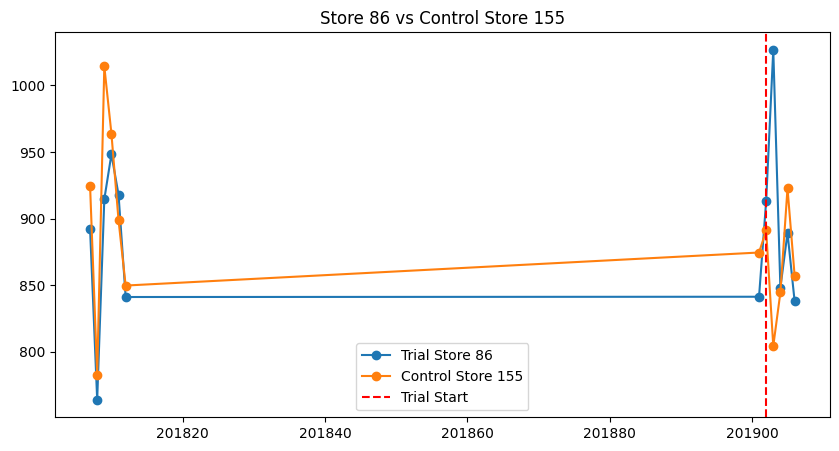

In [71]:
#------------------------------------------------------------------------------------------------------------------------------------------------------
# sort the data 
trial_86 = trial_86.sort_values("YEARMONTH")
control_155 = control_155.sort_values("YEARMONTH")

plt.figure(figsize=(10,5))

plt.plot(
    trial_86["YEARMONTH"],
    trial_86["Total_sales"],
    marker='o',
    label='Trial Store 86'
)

plt.plot(
    control_155["YEARMONTH"],
    control_155["Total_sales"],
    marker='o',
    label='Control Store 155'
)

plt.axvline(
    x=201902,
    color='red',
    linestyle='--',
    label='Trial Start'
)

plt.legend()
plt.title("Store 86 vs Control Store 155")
plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------


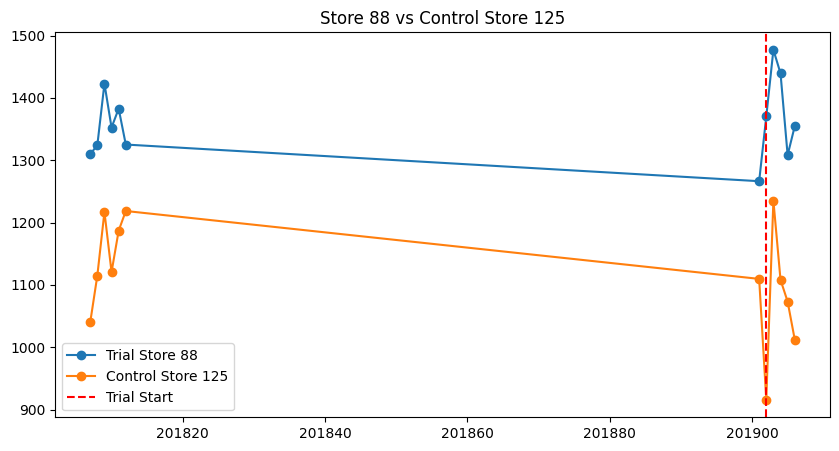

In [72]:
#------------------------------------------------------------------------------------------------------------------------------------------------------
# sort the data 
trial_88 = trial_88.sort_values("YEARMONTH")
control_125 = control_125.sort_values("YEARMONTH")

plt.figure(figsize=(10,5))

plt.plot(
    trial_88["YEARMONTH"],
    trial_88["Total_sales"],
    marker='o',
    label='Trial Store 88'
)

plt.plot(
    control_125["YEARMONTH"],
    control_125["Total_sales"],
    marker='o',
    label='Control Store 125'
)

plt.axvline(
    x=201902,
    color='red',
    linestyle='--',
    label='Trial Start'
)

plt.legend()
plt.title("Store 88 vs Control Store 125")
plt.show()
#------------------------------------------------------------------------------------------------------------------------------------------------------

## Trial Period Analysis

The trial period was defined as February 2019 to April 2019.

During this period, the performance of each trial store was compared against its corresponding control store.

The following measures were evaluated:

- Sales Uplift
- Customer Uplift

These metrics help quantify the impact of the new store layout.

In [74]:
# Compare Trail Period only 
trial_months = [201902, 201903, 201904]
#------------------------------------------------------------------------------------------------------------------------------------------------------

#store 77
trial77_period = trial_77[
    trial_77["YEARMONTH"].isin(trial_months)
]

control233_period = control_233[
    control_233["YEARMONTH"].isin(trial_months)
]
#------------------------------------------------------------------------------------------------------------------------------------------------------

#store 86
trial86_period = trial_86[
    trial_86["YEARMONTH"].isin(trial_months)
]

control155_period = control_155[
    control_155["YEARMONTH"].isin(trial_months)
]
#------------------------------------------------------------------------------------------------------------------------------------------------------

#store 88
trial88_period = trial_88[
    trial_88["YEARMONTH"].isin(trial_months)
]

control125_period = control_125[
    control_125["YEARMONTH"].isin(trial_months)
]

In [78]:
#------------------------------------------------------------------------------------------------------------------------------------------------------
# Calculate Sales Uplift for store 77
trial_sales = trial77_period["Total_sales"].sum()
control_sales = control233_period["Total_sales"].sum()

uplift = (
    (trial_sales - control_sales)
    / control_sales
) * 100
print("Store 77")
print(f"Sales Uplift: {uplift:.2f}%")

# Calculate Customer Uplift
trial_customers = trial77_period["Customers"].sum()

control_customers = control233_period["Customers"].sum()

customer_uplift = (
    (trial_customers - control_customers)
    / control_customers
) * 100

print(f"Customer Uplift: {customer_uplift:.2f}%")
print("--------------------")

#------------------------------------------------------------------------------------------------------------------------------------------------------

# Calculate Sales Uplift
trial_sales = trial86_period["Total_sales"].sum()
control_sales = control155_period["Total_sales"].sum()

uplift = (
    (trial_sales - control_sales)
    / control_sales
) * 100
print("Store 86")
print(f"Sales Uplift: {uplift:.2f}%")

# Calculate Customer Uplift
trial_customers = trial86_period["Customers"].sum()

control_customers = control155_period["Customers"].sum()

customer_uplift = (
    (trial_customers - control_customers)
    / control_customers
) * 100

print(f"Customer Uplift: {customer_uplift:.2f}%")
print("--------------------")
#------------------------------------------------------------------------------------------------------------------------------------------------------

# Calculate Sales Uplift
trial_sales = trial77_period["Total_sales"].sum()
control_sales = control233_period["Total_sales"].sum()

uplift = (
    (trial_sales - control_sales)
    / control_sales
) * 100
print("Store 88")
print(f"Sales Uplift: {uplift:.2f}%")

# Calculate Customer Uplift
trial_customers = trial88_period["Customers"].sum()

control_customers = control125_period["Customers"].sum()

customer_uplift = (
    (trial_customers - control_customers)
    / control_customers
) * 100

print(f"Customer Uplift: {customer_uplift:.2f}%")
print("--------------------")

#------------------------------------------------------------------------------------------------------------------------------------------------------

Store 77
Sales Uplift: 29.13%
Customer Uplift: 23.48%
--------------------
Store 86
Sales Uplift: 9.76%
Customer Uplift: 13.54%
--------------------
Store 88
Sales Uplift: 29.13%
Customer Uplift: 22.54%
--------------------


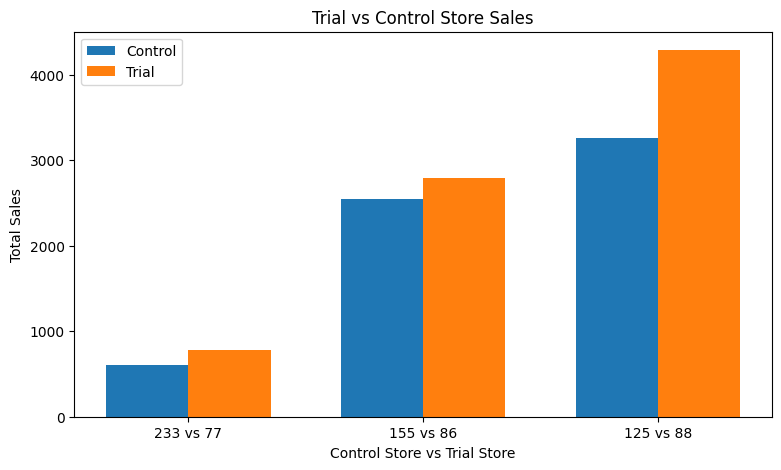

In [84]:
# Visulation of uplift
trial_sales = [
    trial77_period["Total_sales"].sum(),
    trial86_period["Total_sales"].sum(),
    trial88_period["Total_sales"].sum()
]

control_sales = [
    control233_period["Total_sales"].sum(),
    control155_period["Total_sales"].sum(),
    control125_period["Total_sales"].sum()
]

x = np.arange(3)
width = 0.35

plt.figure(figsize=(9,5))

plt.bar(
    x - width/2,
    control_sales,
    width,
    label="Control",
)
plt.bar(
    x + width/2,
    trial_sales,
    width,
    label="Trial",
)

# Store numbers under each pair of bars
labels = [
    "233 vs 77",
    "155 vs 86",
    "125 vs 88"
]
plt.xticks(x, labels)
plt.ylabel("Total Sales")
plt.xlabel("Control Store vs Trial Store")
plt.title("Trial vs Control Store Sales")
plt.legend()

plt.savefig(
    "trial_vs_control_sales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Uplift Results

The results indicate positive performance across all trial stores during the trial period.

### Store 77
- Sales Uplift: 29.13%
- Customer Uplift: 23.48%

### Store 86
- Sales Uplift: 9.76%
- Customer Uplift: 13.54%

### Store 88
- Sales Uplift: 29.13%
- Customer Uplift: 22.54%

# Final Results Summary

| Trial Store | Control Store | Sales Uplift | Customer Uplift | Result           |
| ----------- | ------------- | ------------ | --------------- | ---------------- |
| 77          | 233           | 29.13%       | 23.48%          | Successful       |
| 86          | 155           | 9.76%        | 13.54%          | Moderate Success |
| 88          | 125           | 29.13%       | 22.54%          | Successful       |

# Business Insights
## Store 77
Sales increased by 29.13% during the trial period.
Customer count increased by 23.48%.
The uplift suggests the new layout attracted more purchasing customers.
Recommendation: Roll out the layout to similar stores.

## Store 86
Sales increased by 9.76%.
Customer count increased by 13.54%.
The improvement is positive but smaller than the other trial stores.
Recommendation: Further monitoring is recommended before a full rollout.

## Store 88
Sales increased by 29.13%.
Customer count increased by 22.54%.
Strong customer and sales growth indicates the trial layout was effective.
Recommendation: Roll out the layout to similar stores.


## Recommendation

1. Based on the analysis, the trial can be considered successful.
2. Stores 77 and 88 experienced substantial increases in sales and customer counts during the trial period, suggesting that the new layout effectively improved customer engagement and purchasing behavior.

3. Store 86 also showed positive results, although the uplift was more moderate.

4. It is recommended that the new layout be rolled out to stores with similar characteristics, while continuing to monitor performance in stores similar to Store 86.

5. Overall, the evidence suggests that the trial layout had a positive impact on business performance and should be considered for broader implementation.